# Diemtigen XAI pipeline: 3-segment features + EBM only

This single notebook replaces the previous multi-notebook workflow.
It:
1. builds the **3-segment signal features** dataset,
2. trains/evaluates an **Explainable Boosting Machine (EBM)**,
3. provides native EBM interpretation plots and summaries.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from interpret.glassbox import ExplainableBoostingClassifier


In [2]:
data_root = Path('diemtigen_data')
h5_path = data_root / 'events_mainshocks_foreshocks_aftershocks_15sec_23days.h5'
info_path = data_root / 'info_h5_events_mainshocks_foreshocks_aftershocks_15sec_23days.csv'
features_path = data_root / 'data_features.csv'

info = pd.read_csv(info_path)
label_map = {'foreshock': 0, 'aftershock': 1}
info_fa = info[info['event_type'].isin(label_map)].copy().reset_index(drop=True)
info_fa['label'] = info_fa['event_type'].map(label_map)

info_fa[['event_id', 'event_type', 'label']].head()


,event_id,event_type,label
0,20140417015156,foreshock,0
1,20140417023407,foreshock,0
2,20140417030217,foreshock,0
3,20140417030538,foreshock,0
4,20140417030638,foreshock,0


## Feature Definitions and Interpretation

---

### 1. Time-Domain Features

#### RMS Amplitude

$$
\text{RMS}(x) = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}
$$

- Average signal amplitude (energy content)  
- Higher RMS indicates stronger ground motion  


#### Energy

$$
E(x) = \sum_{i=1}^{N} x_i^2
$$

- Total signal energy  


#### Peak Absolute Amplitude

$$
\max |x|
$$

- Maximum ground motion  
- Indicates impulsiveness of the signal

#### Standard Deviation

$$
\sigma = \sqrt{\frac{1}{N} \sum (x_i - \mu)^2}
$$

- Variability of the signal  
- Similar to RMS but centered  


#### Crest Factor

$$
\text{Crest} = \frac{\max |x|}{\text{RMS}(x)}
$$

- Impulsiveness of the waveform  
- high → sharp peaks (impulsive)  
- low → smoother signal  


#### Zero Crossing Rate (ZCR)

$$
\text{ZCR} = \frac{1}{N-1} \sum \mathbf{1}(x_i \cdot x_{i+1} < 0)
$$

- Proxy for frequency content  
- high → high-frequency content  
- low → low-frequency content  

---

### 2. Envelope Features

The envelope is computed using the Hilbert transform:

$$
E(t) = |\mathcal{H}(x(t))|
$$


#### Envelope Maximum

$$
\max E(t)
$$

- Peak amplitude (smoothed)  
- Less sensitive to oscillations than raw peak  


#### Envelope Area

$$
\sum E(t)
$$

- Total signal strength over time  
- Integrates amplitude evolution  


#### Envelope Decay Slope

$$
\log E(t) = a + b t
$$

- **Feature**: slope $$b$$  

- Rate of energy decay in the coda  
- more negative slope → faster decay  
- less negative slope → longer-lasting energy  


---

### 3. Frequency-Domain Features (PSD)

Computed using Welch’s method $P(f)$


#### Band Power

$$
E_{[f_1,f_2]} = \int_{f_1}^{f_2} P(f) \, df
$$

Bands used:

- 1–5 Hz  
- 5–10 Hz  
- 10–20 Hz  
- 20–45 Hz  

- Energy distribution across frequencies  
- low frequencies → larger-scale motion  
- high frequencies → sharper, localized energy  


#### Spectral Centroid

$$
C = \frac{\sum f \cdot P(f)}{\sum P(f)}
$$

- "center of mass" of frequency content  
- higher → more high-frequency energy  
- lower → more low-frequency energy  


#### Spectral Bandwidth

$$
B = \sqrt{\frac{\sum (f - C)^2 P(f)}{\sum P(f)}}
$$

- Spread of frequencies  
- high → broad spectrum  
- low → narrow frequency band  

---

### 4. Cross-Segment Features

These features compare different waveform phases.


#### Signal-to-Noise Ratio (Proxy)

$$
\text{SNR} = \frac{\text{RMS}_{P}}{\text{RMS}_{noise}}
$$

- Signal strength relative to background  
- high → strong event  
- low → weak or noisy event  


#### Coda-to-P Energy Ratio

$$
\frac{E_{coda}}{E_{P}}
$$

- Energy redistribution after P arrival  
- high → strong scattering / long coda  
- low → more impulsive event   



In [3]:
def safe_ratio(a, b):
    if b is None or np.isnan(b) or abs(b) < 1e-12:
        return np.nan
    return float(a / b)

def rms(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x*x))) if x.size else float("nan")

def energy(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sum(x*x)) if x.size else float("nan")

def peak_abs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.max(np.abs(x))) if x.size else float("nan")

def std(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.std(x)) if x.size else float("nan")

def crest_factor(x: np.ndarray) -> float:
    r = rms(x)
    p = peak_abs(x)
    return float(p / r) if (r and not np.isnan(r) and r > 0) else float("nan")

def zero_crossing_rate(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return float("nan")
    s = np.sign(x)
    s[s == 0] = 1
    return float(np.mean(s[:-1] != s[1:]))

def envelope_hilbert(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    from scipy.signal import hilbert
    return np.abs(hilbert(x))

def env_max(x: np.ndarray) -> float:
    e = envelope_hilbert(x)
    return float(np.max(e)) if e.size else float("nan")

def env_area(x: np.ndarray) -> float:
    e = envelope_hilbert(x)
    return float(np.sum(e)) if e.size else float("nan")

def env_decay_slope(x: np.ndarray, sr: float) -> float:
    e = envelope_hilbert(x)
    if e.size < 10:
        return float("nan")
    e = np.maximum(e, 1e-12)
    t = np.arange(e.size) / float(sr)
    y = np.log(e)
    k0 = int(0.05 * e.size)
    t2, y2 = t[k0:], y[k0:]
    if t2.size < 10:
        return float("nan")
    A = np.vstack([t2, np.ones_like(t2)]).T
    slope, _ = np.linalg.lstsq(A, y2, rcond=None)[0]
    return float(slope)

def psd_features(x: np.ndarray, sr: float, bands=((1,5),(5,10),(10,20),(20,45))):
    from scipy.signal import welch
    x = np.asarray(x, dtype=float)
    out = {}
    if x.size < 32:
        for (a,b) in bands:
            out[f"band_{a}_{b}_pow"] = float("nan")
        out["spec_centroid"] = float("nan")
        out["spec_bandwidth"] = float("nan")
        return out
    f, Pxx = welch(x, fs=sr, nperseg=min(256, x.size))
    for (a,b) in bands:
        m = (f >= a) & (f < b)
        out[f"band_{a}_{b}_pow"] = float(np.trapezoid(Pxx[m], f[m])) if np.any(m) else 0.0
    P = np.maximum(Pxx, 0)
    denom = np.sum(P)
    if denom <= 0:
        out["spec_centroid"] = float("nan")
        out["spec_bandwidth"] = float("nan")
    else:
        centroid = float(np.sum(f * P) / denom)
        bandwidth = float(np.sqrt(np.sum(((f - centroid)**2) * P) / denom))
        out["spec_centroid"] = centroid
        out["spec_bandwidth"] = bandwidth
    return out

In [4]:
SEGMENTS = {
    'noise': (0.0, 1.0),     # pre-P noise
    'p': (1.0, 4.0),         # P arrival + early energy
    'coda': (4.0, 15.0),     # scattered + decay
}
CHANNELS = {'E': 'HHE', 'N': 'HHN', 'Z': 'HHZ'}


def get_event_traces(h5f, event_id: str):
    g = h5f[str(event_id)]
    tr = g['traces']
    keys = list(tr.keys())
    sr = float(tr[keys[0]].attrs.get('sampling_rate', np.nan))

    out = {}
    for comp, chan in CHANNELS.items():
        k = [kk for kk in keys if kk.endswith(chan)]
        out[comp] = np.array(tr[k[0]][:]) if k else None
    return out, sr


In [5]:
rows = []

with h5py.File(h5_path, 'r') as h5f:
    for _, r in info_fa.iterrows():
        eid = str(r['event_id'])
        if eid not in h5f:
            continue

        traces, sr = get_event_traces(h5f, eid)
        if any(traces[c] is None for c in CHANNELS):
            continue

        # Align all channels to the same length
        L = min(traces['E'].size, traces['N'].size, traces['Z'].size)
        for c in traces:
            traces[c] = traces[c][:L].astype(float)

        base = {
            'event_id': eid,
            'label': int(r['label']),
            'event_type': r['event_type'],
            'sampling_rate': sr,
            'npts': L,
        }

        feat = dict(base)

        # Per-segment, per-channel features
        for seg_name, (t0, t1) in SEGMENTS.items():
            i0, i1 = int(round(t0 * sr)), int(round(t1 * sr))

            for comp in ['E', 'N', 'Z']:
                x = traces[comp][i0:i1]
                prefix = f'{comp}_{seg_name}'

                # Time-domain features
                feat[f'{prefix}_rms'] = rms(x)
                feat[f'{prefix}_energy'] = energy(x)
                feat[f'{prefix}_peak_abs'] = peak_abs(x)
                feat[f'{prefix}_std'] = std(x)
                feat[f'{prefix}_crest_factor'] = crest_factor(x)
                feat[f'{prefix}_zcr'] = zero_crossing_rate(x)

                # Envelope features
                feat[f'{prefix}_env_max'] = env_max(x)
                feat[f'{prefix}_env_area'] = env_area(x)
                feat[f'{prefix}_env_decay_slope'] = env_decay_slope(x, sr)

                # Frequency-domain features
                psd = psd_features(x, sr)
                for k, v in psd.items():
                    feat[f'{prefix}_{k}'] = v

        # Cross-segment ratios
        for comp in ['E', 'N', 'Z']:
            feat[f'{comp}_snr_proxy'] = safe_ratio(
                feat[f'{comp}_p_rms'],
                feat[f'{comp}_noise_rms']
            )

            feat[f'{comp}_coda_to_p_energy'] = safe_ratio(
                feat[f'{comp}_coda_energy'],
                feat[f'{comp}_p_energy']
            )

        rows.append(feat)

df_features = pd.DataFrame(rows)
df_features.to_csv(features_path, index=False)

print('Saved:', features_path, 'shape =', df_features.shape)
df_features.head()

Saved: diemtigen_data\data_features.csv shape = (2341, 146)


,event_id,label,event_type,sampling_rate,npts,E_noise_rms,E_noise_energy,E_noise_peak_abs,E_noise_std,E_noise_crest_factor,...,Z_coda_band_10_20_pow,Z_coda_band_20_45_pow,Z_coda_spec_centroid,Z_coda_spec_bandwidth,E_snr_proxy,E_coda_to_p_energy,N_snr_proxy,N_coda_to_p_energy,Z_snr_proxy,Z_coda_to_p_energy
0,20140417015156,0,foreshock,120.0,1801,57.349223,394672.0,115.0,39.139831,2.005258,...,2.693888,1.602471,1.430134,6.356009,0.813419,5.958638,0.473612,12.927494,5.131093,3.196580
1,20140417023407,0,foreshock,120.0,1801,41.918472,210859.0,89.0,34.874178,2.123169,...,3.297301,1.728879,1.014587,4.916458,1.772160,4.228481,0.798926,6.191147,1.191125,1.723482
2,20140417030217,0,foreshock,120.0,1801,113.602377,1548660.0,186.0,51.055196,1.637290,...,3.964625,1.677062,1.244760,5.685991,0.769819,0.781536,1.151989,8.365305,1.697469,9.640666
3,20140417030538,0,foreshock,120.0,1801,97.327026,1136706.0,156.0,30.270448,1.602844,...,2.710471,2.200578,3.229109,10.409564,0.721438,4.390779,0.536043,7.347531,0.612373,1.947691
4,20140417030638,0,foreshock,120.0,1801,35.017734,147149.0,92.0,31.502486,2.627240,...,3.485158,1.919574,0.994569,4.766943,1.014414,14.317464,0.964974,1.400059,0.532890,8.886296


## Train/Evaluate EBM (only model)



In [6]:
df = pd.read_csv(features_path)

y = df['label'].astype(int).values
X = df.drop(columns=['event_id', 'label', 'event_type']).copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

ebm = ExplainableBoostingClassifier(random_state=0, interactions=0)
ebm.fit(X_train, y_train)

proba = ebm.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print({
    'accuracy': accuracy_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'roc_auc': roc_auc_score(y_test, proba),
})
print(classification_report(y_test, pred, target_names=['foreshock', 'aftershock']))


{'accuracy': 0.6076759061833689, 'f1': 0.6290322580645161, 'roc_auc': 0.6363520640116385}
              precision    recall  f1-score   support

   foreshock       0.62      0.55      0.58       234
  aftershock       0.60      0.66      0.63       235

    accuracy                           0.61       469
   macro avg       0.61      0.61      0.61       469
weighted avg       0.61      0.61      0.61       469



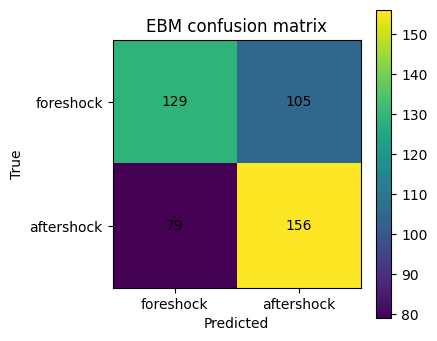

In [7]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation='nearest')
plt.title('EBM confusion matrix')
plt.colorbar()
plt.xticks([0, 1], ['foreshock', 'aftershock'])
plt.yticks([0, 1], ['foreshock', 'aftershock'])
plt.xlabel('Predicted')
plt.ylabel('True')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.show()


## EBM interpretation (native)


In [8]:
def ebm_top_importances(model, topk=20):
    ge = model.explain_global().data()
    out = pd.DataFrame({'feature': ge['names'], 'importance': ge['scores']})
    return out.sort_values('importance', ascending=False).head(topk)

top = ebm_top_importances(ebm, topk=25)
top.head(10)


,feature,importance
119,N_coda_band_20_45_pow,0.102302
117,N_coda_band_5_10_pow,0.098728
27,N_noise_band_5_10_pow,0.070096
44,Z_noise_band_20_45_pow,0.066587
136,Z_coda_spec_bandwidth,0.060028
28,N_noise_band_10_20_pow,0.045410
105,E_coda_spec_centroid,0.038238
134,Z_coda_band_20_45_pow,0.037308
137,E_snr_proxy,0.033290
29,N_noise_band_20_45_pow,0.028869


In [9]:
import re

def segment_from_feature(name):
    if '_noise_' in name:
        return 'noise'
    if '_p_' in name:
        return 'p'
    if '_coda_' in name:
        return 'coda'
    return 'cross_segment'

def channel_from_feature(name):
    m = re.match(r'^([ENZ])_', name)
    return m.group(1) if m else 'derived'

summary = top.copy()
summary['segment'] = summary['feature'].map(segment_from_feature)
summary['channel'] = summary['feature'].map(channel_from_feature)
summary.groupby(['segment', 'channel'], as_index=False)['importance'].sum().sort_values('importance', ascending=False)


,segment,channel,importance
1,coda,N,0.201031
2,coda,Z,0.164679
5,noise,N,0.144375
0,coda,E,0.107342
8,p,N,0.073941
7,p,E,0.069884
6,noise,Z,0.066587
4,noise,E,0.046867
3,cross_segment,E,0.033290
9,p,Z,0.028701


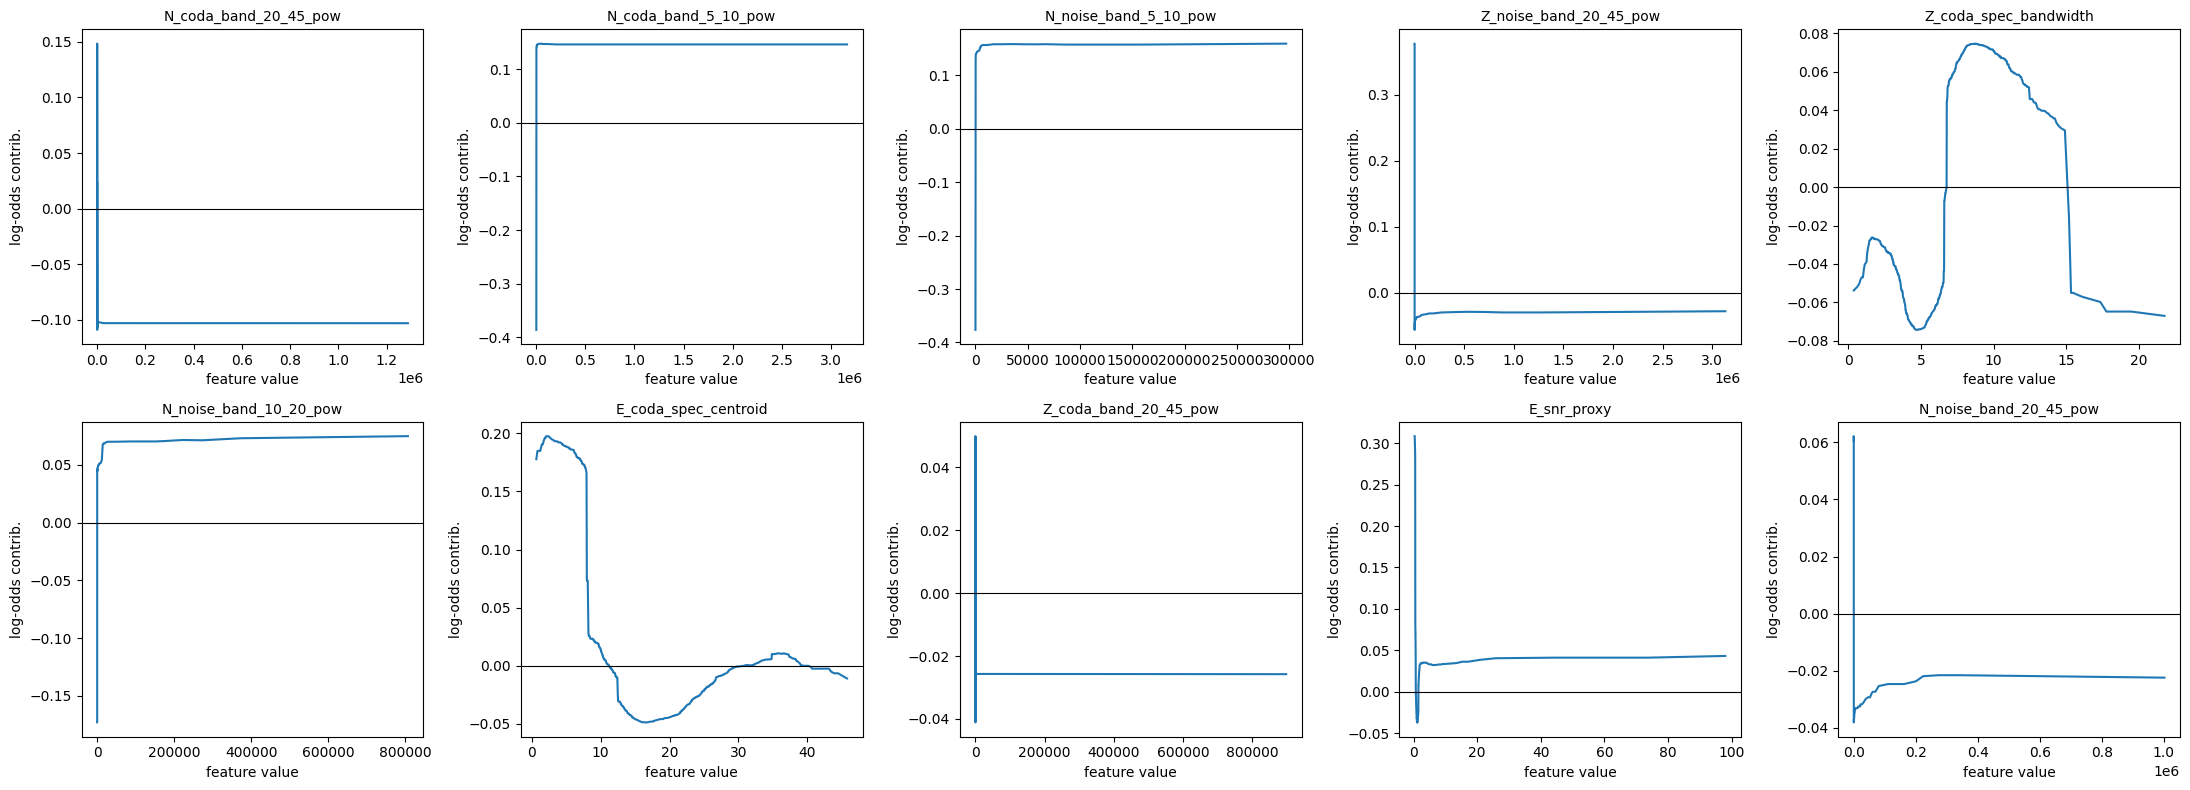

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ebm_top_shapes(ebm, topk=10, nrows=2, ncols=5):
    global_exp = ebm.explain_global()
    global_data = global_exp.data()

    feature_names = global_data["names"]
    importances = np.array(global_data["scores"], dtype=float)

    top_idx = np.argsort(importances)[::-1][:topk]

    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 8))
    axes = axes.flatten()

    for ax, idx in zip(axes, top_idx):
        data = global_exp.data(idx)

        xs = data.get("names")
        ys = data.get("scores")

        if xs is None or ys is None:
            ax.set_title(f"{feature_names[idx]}\n(no data)", fontsize=10)
            ax.axis("off")
            continue

        ys = np.array(ys, dtype=float)

        try:
            xs_num = np.array(xs, dtype=float)
        except Exception:
            xs_num = None

        # EBM often returns bin edges (len(xs)=len(ys)+1)
        if xs_num is not None and len(xs_num) == len(ys) + 1:
            x_plot = 0.5 * (xs_num[:-1] + xs_num[1:])
            ax.plot(x_plot, ys)
        elif xs_num is not None and len(xs_num) == len(ys):
            ax.plot(xs_num, ys)
        else:
            ax.plot(np.arange(len(ys)), ys)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(feature_names[idx], fontsize=10)
        ax.set_ylabel("log-odds contrib.")
        ax.set_xlabel("feature value")

    # Hide unused axes
    for i in range(len(top_idx), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# Run
plot_ebm_top_shapes(ebm, topk=10, nrows=2, ncols=5)